# Class 1 (Monday 7th October)



These tasks are designed to be worked on in the practical class on Monday 7th October.

# Getting to know Numpy

Practice using Numpy by doing the following tasks:

In [1]:
import numpy as np

- Create the vectors $\mathbf{a} = \begin{pmatrix}1\\2\\0\end{pmatrix}$ and $\mathbf{b} = \begin{pmatrix}-3\\\tfrac32\\1\end{pmatrix}$.

In [3]:
a = np.array([1, 2, 0])
b = np.array([-3, 3/2, 1])
print(a,b)

[1 2 0] [-3.   1.5  1. ]


- Create the matrix $A=\begin{pmatrix}1&0&0\\0&2&0\\1&0&1\end{pmatrix}$.

In [6]:
A = np.array([
    [1, 0, 0],
    [0, 2, 0],
    [1, 0, 1]
])
A

array([[1, 0, 0],
       [0, 2, 0],
       [1, 0, 1]])

- Compute the matrix-vector product $Aa$.

In [10]:
A @ a

array([1, 4, 1])

In [9]:
np.dot?

- Compute the dot product $\mathbf{a}\cdot\mathbf{b}$.

In [14]:
a.dot(b)
np.dot(a, b)
a @ b

0.0

- Find a vector that is perpendicular to both $\mathbf{a}$ and $\mathbf{b}$.

In [15]:
np.cross(a, b)

array([ 2. , -1. ,  7.5])

- Find the vector $\mathbf{x}$ such that $A\mathbf{x}=\mathbf{a}$

In [21]:
x = np.linalg.solve(A, a)

x_inv = np.linalg.inv(A) @ a

print(x)
print(x_inv)


[ 1.  1. -1.]
[ 1.  1. -1.]


The following snippet of code defines a function that computes a matrix-vector product. The last two lines should print the same result:
this can be used to check that the function is behaving as expected.

In [22]:
import numpy as np

def slow_matvec(matrix, vector):
    assert matrix.shape[1] == vector.shape[0]
    result = []
    for r in range(matrix.shape[0]):
        value = 0
        for c in range(matrix.shape[1]):
            value += matrix[r, c] * vector[c]
        result.append(value)
    return np.array(result)


# Example of using this function
matrix = np.random.rand(3, 3)
vector = np.random.rand(3)
print(slow_matvec(matrix, vector))
print(matrix @ vector)

[0.96873131 0.88735022 0.90039588]
[0.96873131 0.88735022 0.90039588]


In [56]:
import numpy as np

def fast_matvec(matrix, vector):
    assert matrix.shape[1] == vector.shape[0]
    result = []
    for r in range(matrix.shape[0]):
        #value = 0
        value = matrix[r] @ vector #np.sum(matrix[r] * vector)
        # for c in range(matrix.shape[1]):
        #     value += matrix[r, c] * vector[c]
        result.append(value)
    return np.array(result)


# Example of using this function
matrix = np.random.rand(3, 3)
vector = np.random.rand(3)
print(fast_matvec(matrix, vector))
print(matrix @ vector)

[0.51477289 0.87975244 0.73503158]
[0.51477289 0.87975244 0.73503158]


Using this code as a template, write your own function called `faster_matvec` that computes matrix-vector products by taking the dot product of the matrix with each row.
Check that your function also gives the same result as these two functions.

# Testing with asserts
When writing a code that you want to run on a large HPC system, it is important to test that the code is correct before setting it off.
There are better ways to do this than manually comparing outputs like you did above.

Probably the best way to test your code for correctness is to write some `assert` statements to assert that your function gives the correct result for some small problems that
you know the answer to. For example, the following code tests a function that's been written to add two integers.

In [29]:
def add(a, b):
    return a + b


assert add(1, 1) == 2
assert add(4, 5) == 9

When using floating point numbers, asserts using `==` can fail even when the numbers should be the same (due to differences around the size of machine precision).
For example, the following assert fails (or at least, it fails on my computer using Python 3.10.4):

In [30]:
assert 100 / 3 * 30 == 1000.000000000000000001

AssertionError: 

To avoid this issue, the function `np.isclose` should be used, eg:


In [37]:
import numpy as np
assert np.isclose(100 / 3 * 30, 1000.0, rtol=1e-20)
assert np.allclose(A, A+1e-1, rtol=1e-1)

AssertionError: 

For vectors and matrices, `np.allclose` can be used.


If more detailed inofrmation about *where* and how *big* the differences are. Numpy provides ``numpy.testing`` asserts as well:

In [39]:
import numpy.testing as npt

A = np.ones(shape=(4,4), dtype=np.float64)
B = np.ones(shape=(4,4), dtype=np.float64)
B[2,2] = 4

In [41]:
npt.assert_almost_equal(A,A + 1e-1)

AssertionError: 
Arrays are not almost equal to 7 decimals

Mismatched elements: 16 / 16 (100%)
Max absolute difference: 0.1
Max relative difference: 0.09090909
 x: array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])
 y: array([[1.1, 1.1, 1.1, 1.1],
       [1.1, 1.1, 1.1, 1.1],
       [1.1, 1.1, 1.1, 1.1],
       [1.1, 1.1, 1.1, 1.1]])

In [42]:
npt.assert_equal(A,B)

AssertionError: 
Arrays are not equal

Mismatched elements: 1 / 16 (6.25%)
Max absolute difference: 3.
Max relative difference: 0.75
 x: array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])
 y: array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 4., 1.],
       [1., 1., 1., 1.]])

Note how ``asserts`` are not needed.

Either method is fine for this course.

Write some Python code that test your `faster_matvec` function by computing that matrix-vector product of a random matrix and vector and compares the result to
the result when using `@`.

(Python libraries commonly use the `pytest` library to carry out automated testing. Use of `pytest` is beyond the scope of this course.)

In [44]:
npt.assert_array_almost_equal(matrix @ vector, fast_matvec(matrix,vector))

# Timing a function
You're now going to measure the time it takes to compute matrix-vector products with the two functions `slow_matvec` and `fast_matvec`. The following code snippet measures the time taken
to run a function `f`. This runs the function 1000 times and prints the total time taken.

In [49]:
from timeit import timeit
import time

def f():
    # contents of the function go here
    time.sleep(0.001)
    return 1+ 2


t = timeit(f, number=10)
print(t/1000)

1.0966332999942097e-05


In [50]:
t = %timeit -o f()

1.12 ms ± 40.1 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [54]:
t.average

0.0011241238738571157

Write some Python code that measures the time taken to compute a matrix-vector product of an $n\times n$ matrix and a vector with $n$ entries for $n=2,10,100$ for both `slow_matvec` and `fast_matvec`.
How much is your function faster than `slow_matvec`?

In [58]:
matrix_size = [2, 10, 100]

slow_times = []
fast_times = []

for n in matrix_size:
  test_mat = np.random.rand(n,n)
  test_vec = np.random.rand(n)

  # def test_slow()
  #   return slow_matvec(test_mat, test_vec)

  # def test_fast():
  #   return fast_matvec(test_mat, test_vec)

  # t_slow = timeit(test_slow, number=100)
  # t_fast = timeit(test_fast, number=100)

  t_slow = %timeit -o -q slow_matvec(test_mat, test_vec)
  t_fast = %timeit -o -q fast_matvec(test_mat, test_vec)

  slow_times.append(t_slow.average)
  fast_times.append(t_fast.average)

  print(f"[Slow] [N={n}] Average Run time: {t_slow.average}")
  print(f"[Fast] [N={n}] Average Run Time: {t_fast.average}")


[Slow] [N=2] Average Run time: 5.7593096199993205e-06
[Fast] [N=2] Average Run Time: 4.66463358571413e-06
[Slow] [N=10] Average Run time: 4.3767595514288716e-05
[Fast] [N=10] Average Run Time: 2.0937353641428285e-05
[Slow] [N=100] Average Run time: 0.003831713665713323
[Fast] [N=100] Average Run Time: 0.00020844291241428438


# Plotting with matplotlib
The Python library matplotlib is commonly used to draw plots of data. Matplotlib gives you a lot of freedom to do whatever you want, but this means that it has a lot of options/functions you can use.

(When making plots with matplotlib, you may want to bear in mind that around 4% of people have some form of colourblindness. It can be very helpful to use different line styles and/or markers as well
as colour differences.)

The following example code makes a plot with the curves $y=x$, $y=x^2$ and $y=3x^2$ between $x=1$ and $x=3$.

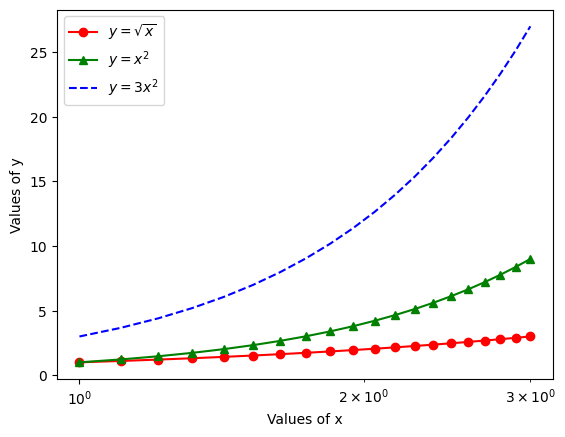

In [61]:
import matplotlib.pylab as plt
import numpy as np

x = np.linspace(1, 3, 20)
y0 = x
y1 = x ** 2
y2 = 3 * x ** 2

plt.plot(x, y0, "ro-", label=r"$y=\sqrt{x}$")
plt.plot(x, y1, "g^-", label="$y=x^2$")
plt.plot(x, y2, "b--", label="$y=3x^2$")

plt.xlabel("Values of x")
plt.ylabel("Values of y")
plt.xscale("log")

plt.legend()

(If you're using a Jupyter notebook, you may need to put the magic command `%matplotlib inline` at the start of the cell to display the plot. If you're running Python from the command line,
you'll need to put `plt.show()` at the end to show the plot.)

Make an alternative version of this plot with both axes using a log scale (hint: `plt.xscale("log")`). (Personally, I think log-log plots are much clearer if the $x$ and $y$ axes use equal tick sizes:
you can do this with `plt.axis("equal")`.) What do you notice about your curves on this log-log plot? (Pen and paper task: starting with $y=ax^b$, work out why what you've observed happens.)

Using matplotlib, make a plot showing the timings you measures in the previous part. Add some more data to your plot to make it more informative.

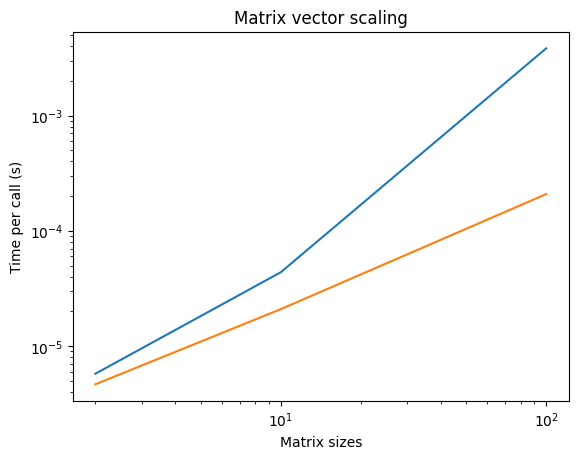

In [68]:
plt.loglog(matrix_size, slow_times)
plt.loglog(matrix_size, fast_times)

plt.xlabel("Matrix sizes")
plt.ylabel("Time per call (s)")
plt.title("Matrix vector scaling")
plt.savefig("myplot.pdf")

# Saving data to a file
If your problem takes a long time to solve, you don't want to have to resolve it to get the data when you want to tweak a matplotlib plot. It's therefore a good idea to save your data to a file
and make a pretty plot with the data separately.

In Jupyter notebooks, this can be acheived by running cells selectively: once you're run the cell with your solver in once, you can tweak your plotting cell and re-run it as many times as you like
without having to re-solve your problem.

When running through a command line interface, you can use the functions `numpy.save` and `numpy.load` to save and load Numpy objects. For example, the following snippet saves a random matrix to a
`.npy` file.

In [69]:
import numpy as np

data = np.random.rand(10, 10)

np.save("my_results.npy", data)

In [72]:
data[:,:] =0.0
data

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [73]:
import numpy as np

data = np.load("my_results.npy")

In [74]:
data

array([[0.32242302, 0.90910797, 0.6606816 , 0.82264672, 0.27234514,
        0.87015174, 0.33466365, 0.40322147, 0.41462211, 0.90909547],
       [0.19764613, 0.43248038, 0.05005422, 0.05971099, 0.49940752,
        0.35090243, 0.46297285, 0.91887236, 0.1440043 , 0.09995462],
       [0.39737338, 0.82217252, 0.23859509, 0.3676873 , 0.95912968,
        0.47739263, 0.97511383, 0.88686411, 0.97228199, 0.7604168 ],
       [0.54811627, 0.82298141, 0.04721431, 0.51158543, 0.31636057,
        0.18539496, 0.70994735, 0.41527412, 0.41043358, 0.53446182],
       [0.47808474, 0.05989448, 0.29665743, 0.35695114, 0.0715883 ,
        0.71231854, 0.59746486, 0.18834731, 0.99318108, 0.76041421],
       [0.96198174, 0.52444103, 0.51928004, 0.02131938, 0.57309977,
        0.18529804, 0.23534848, 0.67105312, 0.60015799, 0.68601437],
       [0.97791549, 0.71099225, 0.76746651, 0.75186792, 0.50835863,
        0.79423811, 0.5512257 , 0.56820291, 0.11836788, 0.28010058],
       [0.7063302 , 0.92550522, 0.4265784

In [76]:
np.savetxt("mydata.csv", data)